In [1]:
# ipl matches analysis - my eda project
# dataset has 900 ipl matches from 2008 to 2022

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

print("done importing")

done importing


In [2]:
# loading the data
df = pd.read_csv("ipl_matches.csv")

print("shape:", df.shape)
print("columns:", df.columns.tolist())
df.head()

shape: (900, 10)
columns: ['season', 'team1', 'team2', 'winner', 'win_by_runs', 'win_by_wickets', 'venue', 'toss_winner', 'toss_decision', 'player_of_match']


,season,team1,team2,winner,win_by_runs,win_by_wickets,venue,toss_winner,toss_decision,player_of_match
0,2008,Rajasthan Royals,Kolkata Knight Riders,Rajasthan Royals,72,0,Feroz Shah Kotla,Rajasthan Royals,bat,Player19
1,2008,Rajasthan Royals,Royal Challengers Bangalore,Rajasthan Royals,0,5,Chinnaswamy Stadium,Royal Challengers Bangalore,field,Player3
2,2008,Delhi Capitals,Sunrisers Hyderabad,Sunrisers Hyderabad,0,6,MA Chidambaram Stadium,Sunrisers Hyderabad,field,Player21
3,2008,Mumbai Indians,Sunrisers Hyderabad,Sunrisers Hyderabad,0,9,Wankhede Stadium,Mumbai Indians,bat,Player42
4,2008,Punjab Kings,Kolkata Knight Riders,Kolkata Knight Riders,0,3,Chinnaswamy Stadium,Punjab Kings,field,Player3


In [3]:
# checking for missing values
# always do this before starting analysis

print("missing values in each column:")
print(df.isnull().sum())
print()
print("basic stats:")
df.describe()

missing values in each column:
season             0
team1              0
team2              0
winner             0
win_by_runs        0
win_by_wickets     0
venue              0
toss_winner        0
toss_decision      0
player_of_match    0
dtype: int64

basic stats:


,season,win_by_runs,win_by_wickets
count,900.000000,900.000000,900.000000
mean,2015.000000,23.572222,2.538889
std,4.322896,31.423837,3.126484
min,2008.000000,0.000000,0.000000
25%,2011.000000,0.000000,0.000000
50%,2015.000000,1.000000,0.000000
75%,2019.000000,46.250000,5.000000
max,2022.000000,98.000000,9.000000


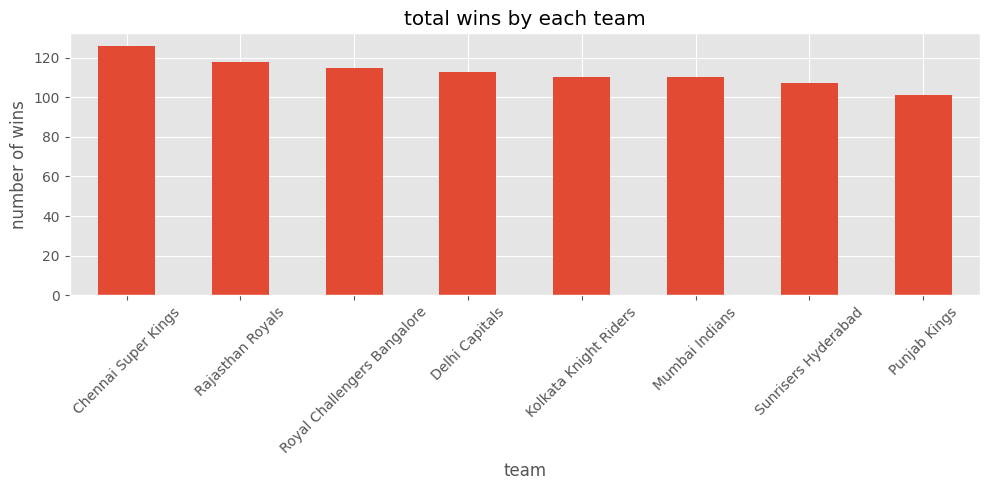

most wins: Chennai Super Kings with 126 wins


In [4]:
# which team won the most matches overall
win_counts = df["winner"].value_counts()

plt.figure(figsize=(10, 5))
win_counts.plot(kind="bar")
plt.title("total wins by each team")
plt.xlabel("team")
plt.ylabel("number of wins")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("most wins:", win_counts.index[0], "with", win_counts.iloc[0], "wins")

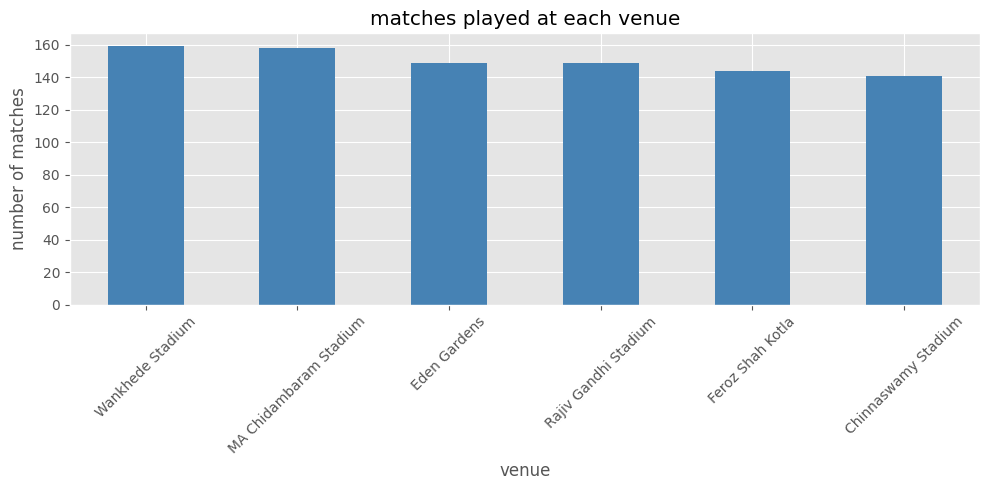

In [5]:
# which venue had most matches
# i was curious about this one

venue_counts = df["venue"].value_counts()

plt.figure(figsize=(10, 5))
venue_counts.plot(kind="bar", color="steelblue")
plt.title("matches played at each venue")
plt.xlabel("venue")
plt.ylabel("number of matches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

total matches: 900
matches where toss winner also won match: 415
percentage: 46.11 %


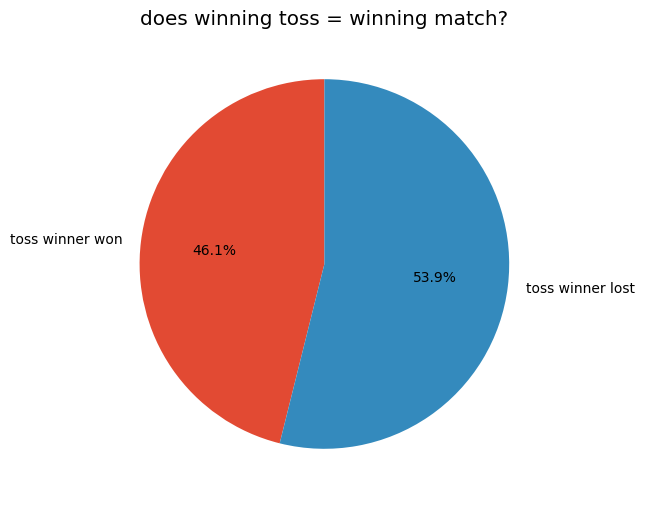

In [6]:
# toss analysis - does winning toss help in winning the match?

toss_win_match_win = df[df["toss_winner"] == df["winner"]].shape[0]
total = df.shape[0]

print("total matches:", total)
print("matches where toss winner also won match:", toss_win_match_win)
print("percentage:", round(toss_win_match_win/total * 100, 2), "%")

# pie chart
labels = ["toss winner won", "toss winner lost"]
sizes = [toss_win_match_win, total - toss_win_match_win]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("does winning toss = winning match?")
plt.show()

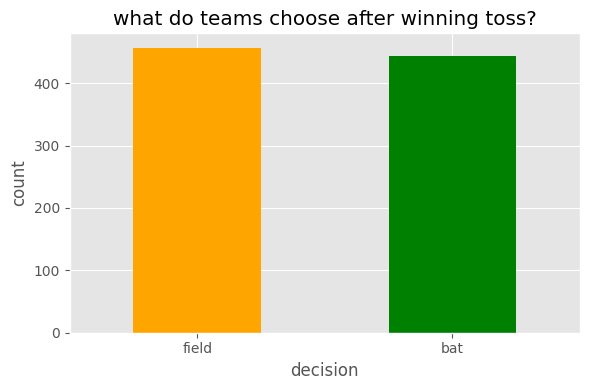

toss_decision
field    457
bat      443
Name: count, dtype: int64


In [8]:
# toss decision analysis
# do teams prefer to bat or field after winning toss?

toss_decision = df["toss_decision"].value_counts()

plt.figure(figsize=(6, 4))
toss_decision.plot(kind="bar", color=["orange", "green"])
plt.title("what do teams choose after winning toss?")
plt.xlabel("decision")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(toss_decision)

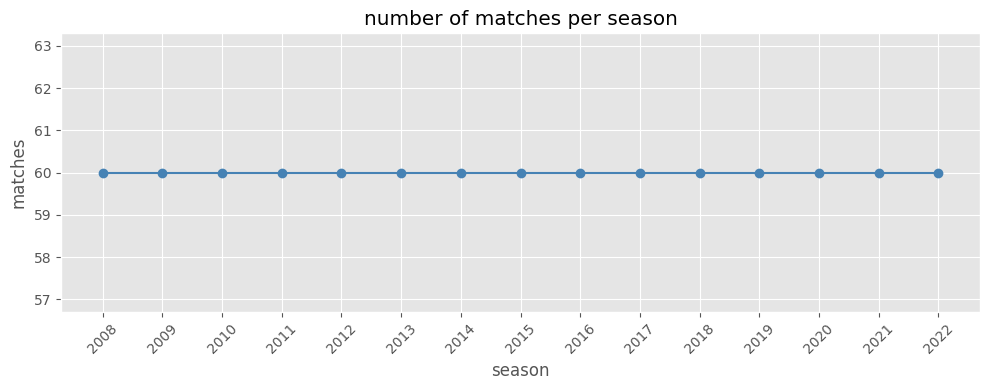

In [9]:
# season wise analysis - how many matches per season?

season_counts = df["season"].value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.plot(season_counts.index, season_counts.values, marker="o", color="steelblue")
plt.title("number of matches per season")
plt.xlabel("season")
plt.ylabel("matches")
plt.xticks(season_counts.index, rotation=45)
plt.tight_layout()
plt.show()

wins by runs: 452
wins by wickets: 448


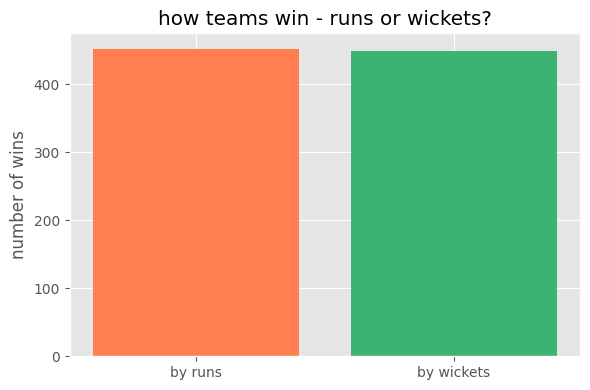

In [10]:
# win by runs vs win by wickets
# wanted to see which winning method is more common

runs_wins = df[df["win_by_runs"] > 0].shape[0]
wicket_wins = df[df["win_by_wickets"] > 0].shape[0]

print("wins by runs:", runs_wins)
print("wins by wickets:", wicket_wins)

plt.figure(figsize=(6, 4))
plt.bar(["by runs", "by wickets"], [runs_wins, wicket_wins], color=["coral", "mediumseagreen"])
plt.title("how teams win - runs or wickets?")
plt.ylabel("number of wins")
plt.tight_layout()
plt.show()

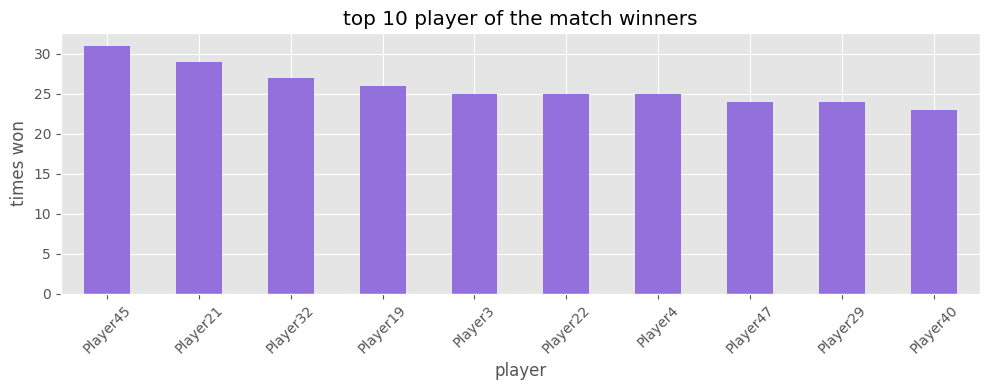

In [11]:
# top player of the match winners
# who won man of the match the most?

top_players = df["player_of_match"].value_counts().head(10)

plt.figure(figsize=(10, 4))
top_players.plot(kind="bar", color="mediumpurple")
plt.title("top 10 player of the match winners")
plt.xlabel("player")
plt.ylabel("times won")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# team performance season wise
# which team dominated which season?

season_winners = df.groupby(["season", "winner"]).size().reset_index(name="wins")

# just checking top team each season
best_per_season = season_winners.sort_values("wins", ascending=False).groupby("season").first().reset_index()

print("best team each season:")
print(best_per_season[["season", "winner", "wins"]].to_string(index=False))

best team each season:
 season                      winner  wins
   2008       Kolkata Knight Riders    12
   2009       Kolkata Knight Riders    10
   2010 Royal Challengers Bangalore    12
   2011         Chennai Super Kings    10
   2012         Chennai Super Kings    12
   2013                Punjab Kings    10
   2014       Kolkata Knight Riders    12
   2015            Rajasthan Royals    11
   2016         Sunrisers Hyderabad    11
   2017            Rajasthan Royals    11
   2018 Royal Challengers Bangalore    14
   2019            Rajasthan Royals    16
   2020                Punjab Kings    11
   2021 Royal Challengers Bangalore    14
   2022              Mumbai Indians    11


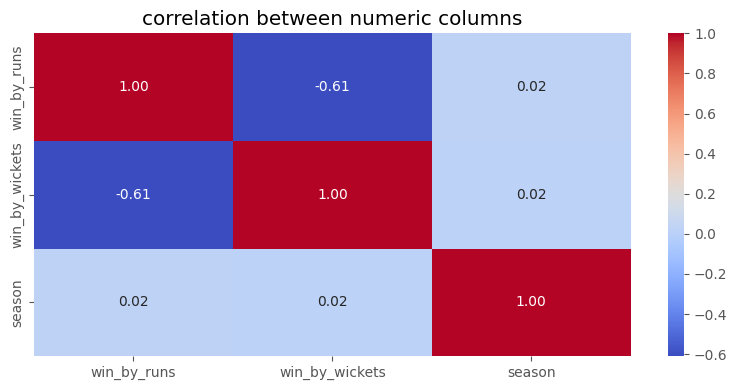

In [14]:
# correlation between win by runs and win by wickets
# just checking if there is any pattern

plt.figure(figsize=(8, 4))
sns.heatmap(df[["win_by_runs", "win_by_wickets", "season"]].corr(), 
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("correlation between numeric columns")
plt.tight_layout()
plt.show()

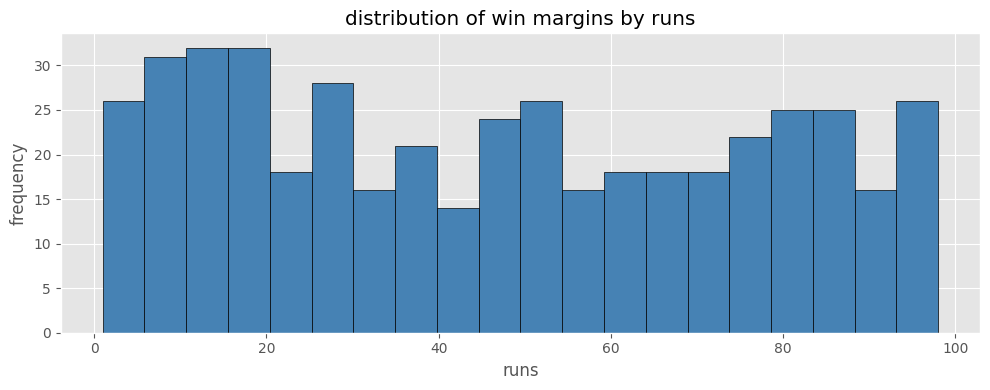

average win margin by runs: 46.94
biggest win by runs: 98


In [17]:
# win margin analysis
# by how many runs do teams usually win?

runs_only = df[df["win_by_runs"] > 0]["win_by_runs"]

plt.figure(figsize=(10, 4))
plt.hist(runs_only, bins=20, color="steelblue", edgecolor="black")
plt.title("distribution of win margins by runs")
plt.xlabel("runs")
plt.ylabel("frequency")
plt.tight_layout()
plt.show()

print("average win margin by runs:", round(runs_only.mean(), 2))
print("biggest win by runs:", runs_only.max())

In [21]:
# so these are the main things i noticed after doing this analysis

print("total matches in dataset:", df.shape[0])
print()
print("most wins:", df["winner"].value_counts().index[0])
print("busiest venue:", df["venue"].value_counts().index[0])
print("toss helped win:", round(toss_win_match_win/total*100, 2), "% matches")
print("avg winning margin:", round(runs_only.mean(), 2), "runs")
print()
print("honestly winning the toss doesn't matter that much ")
print("and most teams prefer fielding first after winning toss")

total matches in dataset: 900

most wins: Chennai Super Kings
busiest venue: Wankhede Stadium
toss helped win: 46.11 % matches
avg winning margin: 46.94 runs

honestly winning the toss doesn't matter that much 
and most teams prefer fielding first after winning toss
